## Model Comparison for Acting Performance Assessment
### This notebook compares different deep learning models for action recognition and performance assessment."

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf

from models.model_trainer import ModelTrainer
from models.cnn_lstm_model import CNNLSTMModel
from models.lstm_model import LSTMModel
from models.bilstm_model import BiLSTMModel
from models.gru_model import GRUModel
from models.rnn_model import RNNModel
from models.cnn_rnn_model import CNNRNNModel
from models.keras_model import KerasModel
from models.pycaret_model import PyCaretModel
from utils.data_loader import DataLoader
from utils.visualization import VisualizationUtils

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All imports successful!")

All imports successful!


In [2]:
# Initialize data loader with correct path
data_loader = DataLoader(dataset_path="../Dataset")

# Print path info
print(f"Looking for dataset at: {data_loader.dataset_path.absolute()}")
print(f"Path exists: {data_loader.dataset_path.exists()}")

# Load dataset
print("\nLoading dataset...")
X, y, y_action, paths = data_loader.prepare_dataset(
    max_videos_per_class=5,  # Use 5 videos per class
    feature_type='aggregated'
)

# Check if data was loaded successfully
if X is None:
    print("❌ No data loaded! Check your dataset path and structure.")
else:
    print(f"\n✅ Dataset shape: {X.shape}")
    print(f"✅ Labels shape: {y.shape}")
    print(f"✅ Number of classes: {len(np.unique(y))}")
    print(f"✅ Class distribution: {np.bincount(y)}")
    print(f"✅ Number of videos: {len(paths)}")
    
    # Data quality check
    print(f"\nData quality check:")
    print(f"  - X dtype: {X.dtype}")
    print(f"  - Contains NaN: {np.isnan(X).any()}")
    print(f"  - Contains Inf: {np.isinf(X).any()}")
    print(f"  - Min value: {X.min():.3f}")
    print(f"  - Max value: {X.max():.3f}")

Looking for dataset at: c:\Graduation Project\V8\notebooks\..\Dataset
Path exists: True

Loading dataset...
Processing Backhand Lob - Good Performance: BackhandLob1_Good.mp4
1/1 [==============================] - 0s 33ms/step
Processing Backhand Lob - Good Performance: BackhandLob2_Good.mp4
1/1 [==============================] - 0s 31ms/step
Processing Backhand Lob - Good Performance: BackhandLob3_Good.mp4
1/1 [==============================] - 0s 31ms/step
Processing Backhand Lob - Good Performance: BackhandLob4_Good.mp4
1/1 [==============================] - 0s 16ms/step
Processing Backhand Lob - Good Performance: BackhandLob5_Good.mp4
1/1 [==============================] - 0s 51ms/step
Processing Backhand Lob - Moderate Performance: BackhandLob1_Moderate.mp4
1/1 [==============================] - 0s 33ms/step
Processing Backhand Lob - Moderate Performance: BackhandLob2_Moderate.mp4
1/1 [==============================] - 0s 23ms/step
Processing Backhand Lob - Moderate Performance: Ba

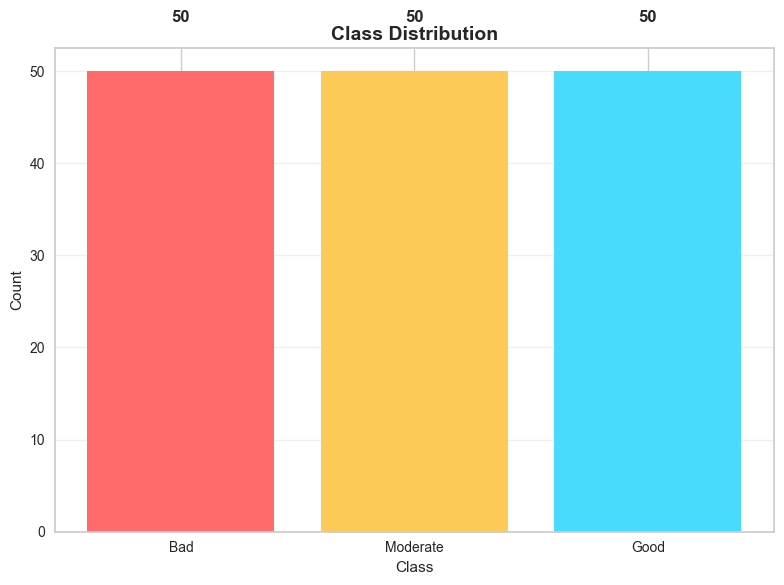

In [3]:
# Only run if data loaded successfully
if X is not None:
    # Visualize class distribution
    viz = VisualizationUtils()
    fig = viz.plot_class_distribution(y, class_names=['Bad', 'Moderate', 'Good'])
    plt.show()
else:
    print("Cannot visualize - no data loaded")

In [4]:
# Only run if data loaded successfully
if X is not None:
    # Split data
    X_train, X_val, X_test, y_train, y_val, y_test = data_loader.split_data(
        X, y, test_size=0.2, val_size=0.1
    )

    print(f"\nTraining set: {X_train.shape}")
    print(f"Validation set: {X_val.shape}")
    print(f"Test set: {X_test.shape}")
    
    print(f"\nTraining class distribution: {np.bincount(y_train)}")
    print(f"Validation class distribution: {np.bincount(y_val)}")
    print(f"Test class distribution: {np.bincount(y_test)}")
else:
    print("Cannot split - no data loaded")

Train: 105, Val: 15, Test: 30

Training set: (105, 180)
Validation set: (15, 180)
Test set: (30, 180)

Training class distribution: [35 35 35]
Validation class distribution: [5 5 5]
Test class distribution: [5 5 5]


In [5]:
# Only run if data loaded successfully
if X is not None:
    # Initialize model trainer
    trainer = ModelTrainer(models_dir="../saved_models")

    # Input shape for flat features
    input_shape = (X_train.shape[1],)

    # Initialize models
    models = trainer.initialize_models(input_shape, num_classes=3)
    print(f"Initialized {len(models)} models:")
    for name in models.keys():
        print(f"  - {name}")
else:
    print("Cannot initialize models - no data loaded")

Initialized 8 models:
  - CNN_LSTM
  - LSTM
  - BiLSTM
  - GRU
  - RNN
  - CNN_RNN
  - Keras_Deep
  - Keras_Medium


In [7]:
# Only run if data loaded successfully
if X is not None:

    # -----------------------------
    # 1️⃣ Basic sanity checks
    # -----------------------------
    print("Checking dataset shapes...")
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_val:", X_val.shape if X_val is not None else None)
    print("y_val:", y_val.shape if y_val is not None else None)

    assert len(X_train) == len(y_train), "Train data mismatch!"
    if X_val is not None:
        assert len(X_val) == len(y_val), "Validation data mismatch!"

    # -----------------------------
    # 2️⃣ Automatically detect classes
    # -----------------------------
    import numpy as np
    num_classes = len(np.unique(y_train))
    print("Detected classes:", num_classes)

    # -----------------------------
    # 3️⃣ Ensure correct label format
    # -----------------------------
    from tensorflow.keras.utils import to_categorical

    if len(y_train.shape) == 1:  # If labels are integers
        print("Converting labels to categorical...")
        y_train = to_categorical(y_train, num_classes)
        if y_val is not None:
            y_val = to_categorical(y_val, num_classes)
        if y_test is not None:
            y_test = to_categorical(y_test, num_classes)

    # -----------------------------
    # 4️⃣ Initialize trainer
    # -----------------------------
    trainer = ModelTrainer(models_dir="../saved_models")

    input_shape = (X_train.shape[1],)

    models = trainer.initialize_models(
        input_shape=input_shape,
        num_classes=num_classes
    )

    print(f"Initialized {len(models)} models:")
    for name in models.keys():
        print(f"  - {name}")

    # -----------------------------
    # 5️⃣ Train models
    # -----------------------------
    results = trainer.train_all_models(
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        epochs=30,
        batch_size=8
    )

else:
    print("Cannot initialize models - no data loaded")

Checking dataset shapes...
X_train: (105, 180)
y_train: (105,)
X_val: (15, 180)
y_val: (15,)
Detected classes: 3
Converting labels to categorical...
Initialized 8 models:
  - CNN_LSTM
  - LSTM
  - BiLSTM
  - GRU
  - RNN
  - CNN_RNN
  - Keras_Deep
  - Keras_Medium

Training CNN_LSTM...
Epoch 1/30


ValueError: in user code:

    File "c:\Graduation Project\V8\venv\lib\site-packages\keras\engine\training.py", line 1284, in train_function  *
        return step_function(self, iterator)
    File "c:\Graduation Project\V8\venv\lib\site-packages\keras\engine\training.py", line 1268, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Graduation Project\V8\venv\lib\site-packages\keras\engine\training.py", line 1249, in run_step  **
        outputs = model.train_step(data)
    File "c:\Graduation Project\V8\venv\lib\site-packages\keras\engine\training.py", line 1050, in train_step
        y_pred = self(x, training=True)
    File "c:\Graduation Project\V8\venv\lib\site-packages\keras\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "c:\Graduation Project\V8\venv\lib\site-packages\keras\engine\input_spec.py", line 298, in assert_input_compatibility
        raise ValueEr

In [ ]:
# Only run if we have results
if X is not None and hasattr(trainer, 'results') and trainer.results:
    # Compare models by accuracy
    comparison = trainer.compare_models(metric='accuracy')

    print("\n=== Model Performance Comparison ===")
    for model, score in comparison.items():
        print(f"{model}: {score:.4f}")
else:
    print("No results to compare")

In [ ]:
# Only run if we have results
if X is not None and hasattr(trainer, 'results') and trainer.results:
    # Visualize comparison
    fig = viz.plot_model_comparison(trainer.results, metric='accuracy')
    plt.show()
else:
    print("Cannot visualize - no results")

In [ ]:
# Only run if we have results
if X is not None and hasattr(trainer, 'results') and trainer.results:
    # Create comparison table
    comparison_data = []
    for name, result in trainer.results.items():
        if 'metrics' in result:
            comparison_data.append({
                'Model': name,
                'Accuracy': result['metrics']['accuracy'],
                'Precision': result['metrics']['precision'],
                'Recall': result['metrics']['recall'],
                'F1-Score': result['metrics']['f1_score']
            })

    df_comparison = pd.DataFrame(comparison_data)
    df_comparison = df_comparison.sort_values('Accuracy', ascending=False)
    display(df_comparison)
else:
    print("No data to display")

In [ ]:
# Only run if we have results
if X is not None and hasattr(trainer, 'results') and trainer.results:
    # Get best model
    best_name, best_model = trainer.get_best_model(metric='f1_score')
    print(f"Best model: {best_name}")

    # Evaluate best model
    if best_model:
        # Get predictions
        y_pred = best_model.predict(X_test)
        
        # Classification report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=['Bad', 'Moderate', 'Good']))
        
        # Confusion matrix
        fig = best_model.plot_confusion_matrix(y_test, y_pred, class_names=['Bad', 'Moderate', 'Good'])
        plt.show()
else:
    print("Cannot evaluate - no results")

In [ ]:
# Only run if we have results
if X is not None and hasattr(trainer, 'results') and trainer.results:
    # Create ensemble prediction
    ensemble_results = trainer.create_ensemble_prediction(X_test)

    if ensemble_results:
        # Evaluate ensemble
        ensemble_accuracy = accuracy_score(y_test, ensemble_results['ensemble_pred'])
        voting_accuracy = accuracy_score(y_test, ensemble_results['voting_pred'])
        
        print(f"Ensemble (weighted) accuracy: {ensemble_accuracy:.4f}")
        print(f"Ensemble (voting) accuracy: {voting_accuracy:.4f}")
        
        # Compare with individual models
        individual_accuracies = [trainer.results[name]['metrics']['accuracy'] 
                                 for name in trainer.results.keys() 
                                 if 'metrics' in trainer.results[name]]
        
        print(f"\nIndividual models: {np.mean(individual_accuracies):.4f} ± {np.std(individual_accuracies):.4f}")
        print(f"Best individual: {np.max(individual_accuracies):.4f}")
else:
    print("Cannot create ensemble - no results")

### Save Results

In [ ]:
# Only run if we have results
if X is not None and hasattr(trainer, 'results') and trainer.results:
    # Save all models
    summary = trainer.save_all_models()
    print("\nModels saved successfully!")
    
    # Print summary
    print("\nSummary of results:")
    for model_name, metrics in summary.items():
        print(f"\n{model_name}:")
        for metric_name, value in metrics.items():
            print(f"  {metric_name}: {value:.4f}")
else:
    print("No models to save")

## Conclusion
### Based on the comparison above, we can identify the best model for our acting performance assessment system.

In [ ]:
# Print final recommendations
if X is not None and hasattr(trainer, 'results') and trainer.results and ensemble_results:
    best_ensemble_accuracy = max(ensemble_accuracy, voting_accuracy)
    best_individual_accuracy = np.max(individual_accuracies) if individual_accuracies else 0
    
    print("\n" + "="*50)
    print("RECOMMENDATIONS")
    print("="*50)
    
    if best_ensemble_accuracy > best_individual_accuracy:
        print("✅ Use ensemble method for best performance")
        print(f"   Ensemble accuracy: {best_ensemble_accuracy:.4f}")
        print(f"   Best individual: {best_individual_accuracy:.4f}")
        
        # Show which ensemble method
        if ensemble_accuracy > voting_accuracy:
            print(f"\n   Best ensemble: Weighted averaging ({ensemble_accuracy:.4f})")
        else:
            print(f"\n   Best ensemble: Voting ({voting_accuracy:.4f})")
    else:
        print(f"✅ Use {best_name} for best performance")
        print(f"   Accuracy: {best_individual_accuracy:.4f}")
else:
    print("\nRun all previous cells first to get recommendations")